In [462]:
import torch
import numpy as np
import pandas as pd
import nibabel as nib
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from torch import nn, distributions

In [463]:
class batched_RBF(nn.Module):
  def __init__(self, sigma=1.0, lengthscale=2.0):
    super().__init__()

    self.sigma = nn.Parameter(torch.tensor(sigma))
    self.lengthscale = nn.Parameter(torch.tensor(lengthscale))
    


  def covariance(self, x1, x2):

    diff = x1-x2
    dist = (diff**2).sum()

    return (self.sigma**2)*torch.exp(-0.5*dist/(self.lengthscale**2))


  def forward(self, X, Z, diag=False):
    
    if diag:
      return (self.sigma**2).unsqueeze(-1).expand(-1, X.size(0))
    

    result = torch.vmap(lambda x: torch.vmap(lambda y: self.covariance(x, y))(X))(Z)
    return torch.transpose(result, -1, 0)

In [464]:
class WSVGP(nn.Module):
  def __init__(self, kernel, dim=1, M=50, jitter=1e-4):
    super().__init__()
    self.kernel = kernel
    self.jitter = jitter
    
    self.Z = nn.Parameter(torch.randn((M, dim))) #choose random inducing points
   
    self.Lu = nn.Parameter(torch.randn((M,M)))
    self.mu = nn.Parameter(torch.zeros((M,)))
    self.constraint = constraints.lower_cholesky


  def kernel_forward(self, X, Z, **args):
    
    return self.kernel(X, Z, **args)
  
  def forward_kernels(self, X, **args):

    Kxx = self.kernel(X, X, diag=True)  #shape L x N
    Kzx = self.kernel(self.Z, X) #shape L x M x N
    Kzz = self.kernel(self.Z, self.Z).contiguous() #shape L x M x M

    return Kxx, Kzx, Kzz

  def forward(self, X, verbose=False, **args):

    if verbose:
      print('calculating kernels')

    Kxx, Kzx, Kzz = self.forward_kernels(X, **args)
    Kzz = add_jitter(Kzz, self.jitter)

    if verbose:
      print('calculating cholesky')
    L = torch.linalg.cholesky(Kzz) #shape L x M x M
   
    if verbose:
        print('calculating W')
   

    Wt = torch.linalg.solve_triangular(L, Kzx, upper=False)  #(Lzz)-1 @ Kzx
    W = torch.transpose(Wt, -2, -1) # Kxz@(Lzz)-T, shape # L x N x M
    Lu = transform_to(self.constraint)(self.Lu) #shape L x M x M
    # S = Lu @ torch.transpose(Lu, -2, -1) # shape L x M x M

    # S = transform_to(self.constraint)(self.S)

    if verbose:
        print('calculating cov_diag')

    cov_diag = Kxx - torch.sum(W**2, dim=-1)
    cov_diag = torch.clamp(cov_diag, min=0.0)
    cov_diag = cov_diag + torch.sum(((W@Lu)**2), dim=-1)

    # cov_diag = torch.clamp(cov_diag, min=1e-4)

    if verbose:
      print('calculating mean')

    mean = W @ (self.mu.unsqueeze(-1))
    mean = torch.squeeze(mean)
    
    if verbose:
      print(torch.min(cov_diag))

    qF = distributions.Normal(mean, cov_diag ** 0.5)
    qZ = distributions.MultivariateNormal(self.mu, scale_tril=Lu)

    pZ = None
    return qF, qZ, pZ



In [465]:
class Factorization(nn.Module):
  def __init__(self, prior, y, L=10):
    super().__init__()
    D, N = y.shape
    self.prior = prior
    self.W = nn.Parameter(torch.rand((D, L)))

  def get_rate(self, prior_samples):
    F = prior_samples
    W = self.W
    Z = torch.matmul(W, F) #shape ExDxN
    return Z


class Gaussian(Factorization):
  def __init__(self, gp, y, L=10):
    super().__init__(prior=gp, y=y, L=L)
    D, N = y.shape
    self.sigma = nn.Parameter(torch.tensor(1.0))

  def forward(self, X, E=10, verbose=False, **kwargs):
    sigma = torch.nn.functional.softplus(self.sigma)
    qF, qU, pU = self.prior(X=X, verbose=verbose, **kwargs)
    F = qF.rsample((E,))
    Z = self.get_rate(F)
    pY = distributions.Normal(F, sigma)
    return pY, qF, qU, pU
  

  def forward_batched(self, X, idx, E=10, verbose=False, **kwargs):
    qF, qU, pU = self.prior(X=X[idx], verbose=verbose, **kwargs)
    F = qF.rsample((E,))
    Z = self.get_rate(F)
    sigma = torch.nn.functional.softplus(self.sigma)
    pY = distributions.Normal(F, sigma)

    return pY, qF, qU, pU

In [466]:
# file_path = '/gladstone/engelhardt/home/lchumpitaz/ds002_R2.0.5/sub-01/anat/sub-01_T1w.nii'

file_path = '/gladstone/engelhardt/home/lchumpitaz/ds002_R2.0.5/sub-01/func/sub-01_task-probabilisticclassification_run-01_bold.nii'
tsv_path = '/gladstone/engelhardt/home/lchumpitaz/ds002_R2.0.5/sub-01/func/sub-01_task-probabilisticclassification_run-01_events.tsv'

In [467]:
df = pd.read_csv( tsv_path, delimiter='\t')
df

,onset,duration,trial_type,feedback,TrialNum,StimCond,StimulusNum,Response,response_time,Correct,Feedback
0,0.116,2.0,feedback,-1.0,1,1,3,L,2.957,0,R
1,4.612,2.0,feedback,1.0,2,1,6,R,1.127,1,R
2,9.082,2.0,feedback,1.0,3,1,4,R,1.351,1,R
3,13.589,2.0,feedback,1.0,4,1,4,R,1.150,1,R
4,18.206,2.0,feedback,-1.0,5,1,11,R,2.359,0,L
...,...,...,...,...,...,...,...,...,...,...,...
75,337.623,2.0,feedback,1.0,76,1,10,R,1.761,1,R
76,342.113,2.0,feedback,1.0,77,1,10,R,1.210,1,R
77,346.676,NaN,NaN,NaN,78,1,0,R,0.795,-,-
78,351.177,NaN,NaN,NaN,79,1,0,R,0.439,-,-


In [468]:
# Load the .nii file
img = nib.load(file_path)

# Access the image data as a NumPy array
data = img.get_fdata()

# Print out basic information about the data
print("Shape of the data:", data.shape)  # Dimensions of the image data (e.g., 3D shape)
print("Data type:", data.dtype)  # Data type (e.g., float32)
print("Header information:", img.header)  # Metadata about the image

Shape of the data: (64, 64, 25, 180)
Data type: float64
Header information: <class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  4  64  64  25 180   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : int16
bitpix          : 16
slice_start     : 0
pixdim          : [1.    3.125 3.125 5.    2.    0.    0.    0.   ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 1360.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b'FSL4.0'
aux_file        : b''
qform_code      : unknown
sform_code      : unknown
quatern_b       : 0.0
quatern_c       : 0.0
quatern_d       : 0.0
qoffset_x   

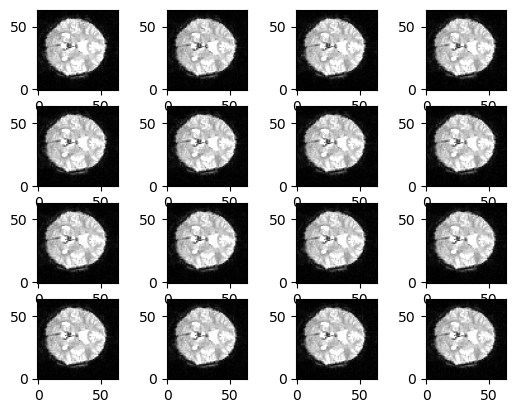

In [469]:
vmin = np.percentile(data[:, :, 10], 5)
vmax = np.percentile(data[:, :, 10], 95)

for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(data[:, :, 10, 10*i], cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
    # plt.axis('off')
    # plt.show()

In [470]:
data.shape

(64, 64, 25, 180)

In [358]:
from sklearn.decomposition import NMF

In [364]:
L=10
model = NMF(n_components=L, init='random', random_state=0, max_iter=10000, alpha_H=2e-1)

In [365]:
data_reshaped = data.reshape(-1, 180)

In [366]:
data.shape

(64, 64, 25, 180)

In [367]:
W = model.fit_transform(data_reshaped)
H = model.components_

/gladstone/engelhardt/home/lchumpitaz/miniconda3/envs/gpzoo/lib/python3.9/site-packages/sklearn/decomposition/_nmf.py:1710: ConvergenceWarning: Maximum number of iterations 10000 reached. Increase it to improve convergence.
  warnings.warn(


In [368]:
W.shape

(102400, 10)

In [372]:
W_reshaped = W.reshape(64, 64, 25, L)

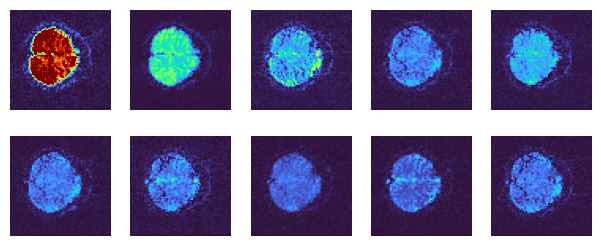

In [373]:
vmin = np.percentile(W, 1)
vmax = np.percentile(W, 99)
plt.figure(figsize=(5*1.5, 2*1.5))
for i in range(L):
    plt.subplot(2, 5, i+1)
    plt.imshow(W_reshaped[:, :, 19, i], origin='lower', cmap='turbo', vmin=vmin, vmax=vmax)
    # plt.imshow(W_reshaped[:, :, 12, i], origin='lower', cmap='turbo')
    plt.axis('off')
    # plt.show()

In [374]:
reconstruct = (W @H).reshape(64, 64, 25, 180)

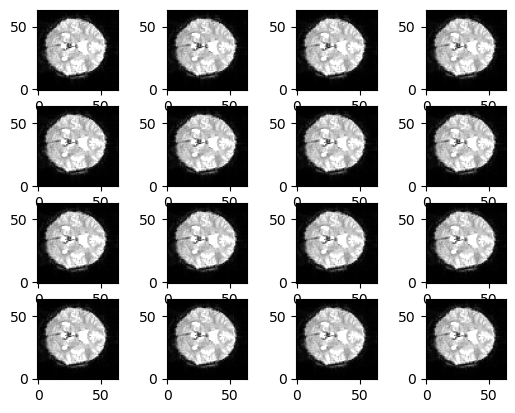

In [375]:
vmin = np.percentile(reconstruct[:, :, 10], 5)
vmax = np.percentile(reconstruct[:, :, 10], 95)

for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(reconstruct[:, :, 10, 10*i], cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
    # plt.axis('off')
    # plt.show()

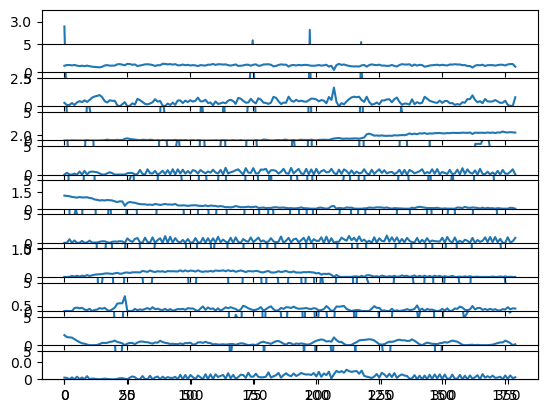

In [387]:
# plt.subplot(L+1,1, 1)
plt.plot(df.onset, df.response_time)
for i in range(L):
    plt.subplot(L+1,1, i+2)
    plt.plot(H[i])
    plt.ylim([0, 5])

In [377]:
np.mean((data-reconstruct)**2)

73.09014732688514

In [378]:
from sklearn.gaussian_process import GaussianProcessRegressor

In [379]:
from sklearn.gaussian_process.kernels import RBF

In [380]:
def map_values(x):
    if x == 'L':
        return -1
    elif x == 'R':
        return 1
    else:
        return 0

# Use numpy vectorize to apply the function element-wise
vectorized_map = np.vectorize(map_values)
result = vectorized_map(df.Response.to_numpy())


In [381]:
gpr = GaussianProcessRegressor(kernel=RBF(),random_state=0).fit(df.onset.to_numpy().reshape(-1, 1), result.reshape(-1, 1))

In [382]:
gpr

GaussianProcessRegressor(kernel=RBF(length_scale=1), random_state=0)

In [383]:
prediction = gpr.predict(np.linspace(0, 359, 180, dtype=int).reshape(-1, 1))

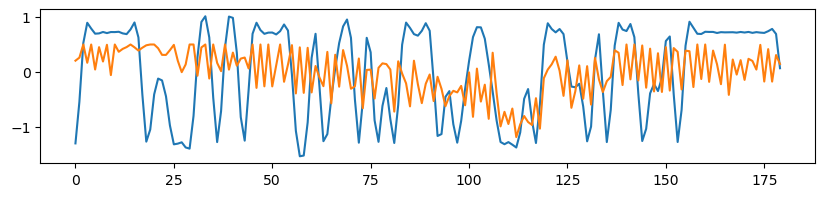

In [402]:
plt.figure(figsize=(10, 2))
plt.plot(prediction- np.mean(prediction))
# plt.plot(H[2]-np.mean(H[2]))
plt.plot(-H[9]+np.mean(H[9]))

In [401]:
np.corrcoef(prediction, H[9])

array([[ 1.        , -0.25184425],
       [-0.25184425,  1.        ]])

In [414]:
data_normed = data_reshaped - np.mean(data_reshaped, axis=0, keepdims=True)

In [415]:
C = data_normed.T @ data_normed

In [416]:
U, S, Vt = np.linalg.svd(C)

In [422]:
data (data_normed @ U)

array([[ 1.96462681e+03, -1.99916771e+00,  1.07517339e+00, ...,
         2.06663531e-03, -3.45131989e-02, -1.52400817e-02],
       [ 1.96462681e+03, -1.99916771e+00,  1.07517339e+00, ...,
         2.06663531e-03, -3.45131989e-02, -1.52400817e-02],
       [ 1.96462681e+03, -1.99916771e+00,  1.07517339e+00, ...,
         2.06663531e-03, -3.45131989e-02, -1.52400817e-02],
       ...,
       [ 1.83231475e+03, -4.54002685e+00,  8.02207243e+00, ...,
        -7.20913089e+00, -8.46261525e+00,  4.97953082e+00],
       [ 1.82908000e+03, -1.54652917e+00,  9.02727705e+00, ...,
        -2.68353702e+00, -5.17512042e-01, -2.31458624e+00],
       [ 1.83782144e+03, -2.06263654e+00, -7.19226604e+00, ...,
         3.40968797e+00, -2.55039357e+00,  1.84138873e+00]])

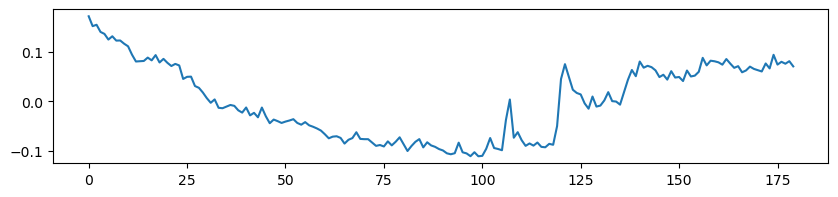

In [435]:
plt.figure(figsize=(10, 2))
plt.plot(-U[:, 2])

In [454]:
find_correlation = lambda x: np.corrcoef(prediction, x
                                        )[0, 1]
find_correlation(prediction, U[:, 3])

-0.048733379244178775

In [458]:
vectorized_correlations = np.vectorize(find_correlation)

vectorized_correlations(prediction, U)

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])